# BIPN 162 Final Project Code Notebook
*title of project*

*Alton Gu, Margaret Jones, Laura Liang*

## idk delete if theres nothing we care to write 

* hi

## Setup
*Are there packages that need to be imported, or datasets that need to be downloaded?*

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import decomposition
from sklearn.datasets import fetch_openml

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.layers import BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

import tensorflow as tf
tf.random.set_seed(42)

!pip install -q -U keras-tuner
from keras_tuner.tuners import Hyperband, BayesianOptimization
from keras import ops

import IPython

import shutil
import os

import scipy
from scipy import linalg as LA
from scipy.stats import pearsonr

import shap 
from shap.explainers._deep.deep_tf import op_handlers


In [5]:
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")

print(f"Python version: {os.sys.version}")

Keras version: 3.12.0
TensorFlow version: 2.18.0
Pandas version: 2.3.3
Numpy version: 2.2.6
Scipy version: 1.15.2
Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]


## Data Wrangling

### [placeholder but new data set]

### Wrangling of Reference Dataset (Gomari et al.)

In [6]:
df_schizo = pd.read_csv('Schizophrenia_metabolite_data.csv')
df_schizo['Disease'] = 'Schizo'
df_AML = pd.read_csv('AML_metabolite_data.csv')
df_AML['Disease'] = 'AML'
df_diabetes = pd.read_csv('QMDiab_metabolite_data.csv')
df_diabetes['Disease'] = 'Diab'

combined_df = pd.concat([df_schizo, df_AML, df_diabetes], join='inner')
meta = combined_df[['Disease']]
metabolite_ids = combined_df.columns.tolist()
combined_df_numeric = combined_df.drop(columns=['Disease'])
# combined_df_numeric = combined_df_numeric.drop(combined_df_numeric.index[0], axis=0) # Drop the first row which contains non-numeric values
combined_df_numeric = combined_df_numeric.astype(float) # Convert all values to float
print(combined_df.head())
print(combined_df.shape)

     M33228    M35186    M34214    M34419    M34395    M34389    M35628  \
0 -0.224790  0.367972  0.213836  0.034424 -0.563072 -0.822089 -0.043932   
1 -1.365763 -0.250218 -1.102545  0.106423  0.547012  0.831003 -0.235921   
2  1.361526  1.419471  0.095614  1.458757 -0.131300  0.118827  1.122446   
3 -1.129735 -0.605956 -0.677170 -0.660245  1.392298  1.474983 -0.627671   
4 -0.402553 -0.924436  0.203205  0.649445 -0.653498 -0.428191 -0.667663   

     M33230    M21127    M33955  ...    M37203    M35527    M37190    M37198  \
0  0.765081 -1.229083  0.376804  ...  0.668735 -1.156433  1.380834  1.028611   
1  0.485585 -0.849375  0.587461  ...  0.910195 -0.636947  1.442837 -0.200371   
2  0.505534 -0.656467  1.113982  ... -3.679084 -0.677344 -3.368232  1.096145   
3  0.034415 -1.640713 -0.864807  ...  0.551563 -1.768515  1.591040  1.499522   
4 -0.650306 -0.145957 -0.191565  ...  1.548937  1.241594  0.203979  2.095742   

     M38178    M39379    M38768    M37506    M37097  Disease  
0 -0.

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(combined_df_numeric, meta['Disease']):
    input_train, input_test = combined_df_numeric.iloc[train_index], combined_df_numeric.iloc[test_index]
    result_train, result_test = meta['Disease'].iloc[train_index], meta['Disease'].iloc[test_index]

print(f"Training set size: {len(input_train)}")
print(f"Testing set size: {len(input_test)}")

del combined_df, combined_df_numeric, df_schizo, df_AML, df_diabetes

Training set size: 515
Testing set size: 129


In [8]:
# Load your metadata (the image you provided)
metadata_df = pd.read_csv('metabolite_annotations.csv')

# Set the ID as the index for quick searching
metadata_lookup = metadata_df.set_index('COMP_IDstr')

# Confirmation of VAE Pipeline (Gomari et al.)

The parameter optimization and VAE code are directly copied from the Github attached to the paper. Minor tweaks were made to ensure that the code ran smoothly AND to cut down on runtime (in the interest of this project).

### Parameter Optimization

In [67]:
# Data & model configuration
batch_size = 32
no_epochs = 1000 #lets keep it shorter for now haha
latent_dim = 18

original_dim = input_train.shape[1]
input_shape = (original_dim,)
# recommended to do this here: https://www.tensorflow.org/tutorials/keras/keras_tuner
class ClearTrainingOutput(tf.keras.callbacks.Callback):
    def on_train_end(*args, **kwargs):
     IPython.display.clear_output(wait = True)
        
        
def model_builder(hp):
    # # =================
    # # Encoder
    # # =================

    # Definition
    i       = Input(shape=input_shape, name='encoder_input')
    
    x       = Dense(hp.Int('encoder_units',
                           min_value=30,
                           max_value=150,
                           step=10))(i)
    x       = LeakyReLU()(x)
   
    
    mu      = Dense(latent_dim, name='latent_mu')(x)
    sigma   = Dense(latent_dim, name='latent_sigma')(x)

    # Define sampling with reparameterization trick
    def sample_z(args):
        mu, sigma = args
        batch     = ops.shape(mu)[0]
        dim       = ops.shape(mu)[1]
        eps       = K.random.normal(shape=(batch, dim))
        return mu + ops.exp(sigma / 2) * eps

    # Use reparameterization trick to ....??
    z       = Lambda(sample_z, output_shape=(latent_dim, ), name='z')([mu, sigma])

    # Instantiate encoder
    encoder = Model(i, [mu, sigma, z], name='encoder')
    
    # =================
    # Decoder
    # =================

    # Definition
    d_i   = Input(shape=(latent_dim, ), name='decoder_input')
    
    x     = Dense(hp.Int('decoder_units',
                           min_value=30,
                           max_value=150,
                           step=10))(d_i)
    x     = LeakyReLU()(x)
        
    o     = Dense(original_dim)(x)

    # Instantiate decoder
    decoder = Model(d_i, o, name='decoder')
    
    # =================
    # VAE as a whole
    # =================
    beta = hp.Float('kl_beta', min_value=1e-4, max_value=1e-2, sampling='LOG', default=1e-3)
    # Define loss
    def kl_reconstruction_loss(true, pred):
      # Reconstruction loss
        reconstruction_loss = ops.mean(ops.square(true - pred), axis=-1)
        reconstruction_loss *= original_dim

        # 2. KL divergence loss 
        # REPLACE tf.exp or K.exp with ops.exp
        # REPLACE K.square with ops.square
        kl_loss = 1 + sigma - ops.square(mu) - ops.exp(sigma)
        kl_loss = ops.sum(kl_loss, axis=-1)
        kl_loss *= -0.5
        
        weighted_kl = kl_loss * beta

        return ops.mean(reconstruction_loss + weighted_kl)

    # Instantiate VAE
    vae_outputs = decoder(encoder(i)[2])
    vae         = Model(i, vae_outputs, name='vae')


    # Define optimizer
    optimizer = Adam(hp.Float(
        'learning_rate',
        min_value=1e-4,
        max_value=1e-2,
        sampling='LOG',
        default=1e-3
    ))

    
    # Use a basic string for the optimizer and loss to avoid 
    # complex objects that trigger the 'experimental' flags
    vae.compile(
        optimizer='adam', 
        loss='mse',
        metrics=['mse']
    )
    
    # Manually set this to True to bypass the 'must call compile' check
    vae.compiled = True 
    
    return vae
    
# Set tuner parameters
tuner = Hyperband(
    model_builder,
    objective='mse',
    # Original is 2, upping to 3 to make tuning more aggressive and faster, since we have a lot of hyperparameters to tune and a small dataset
    factor=2,
    # Decreasing max_epochs in the interest of time
    max_epochs=50,
    directory='hyperband_optimization',
    project_name='gomari_vae',
    overwrite=True)
tuner.search_space_summary()
# Run Tuner
# Runtime on MacBook Pro 2017: 01h 15m

Search space summary
Default search space size: 4
encoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 30, 'max_value': 150, 'step': 10, 'sampling': 'linear'}
decoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 30, 'max_value': 150, 'step': 10, 'sampling': 'linear'}
kl_beta (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [10]:
X_train_numeric = input_train.astype('float32').values
X_test_numeric = input_test.astype('float32').values
X_train_pure = np.array(input_train.values, dtype='float32')
X_test_pure  = np.array(input_test.values, dtype='float32')

print(X_train_pure.shape)
print(X_test_pure.shape)
print(X_train_pure)

(515, 162)
(129, 162)
[[-0.94654447  0.14561985  0.33450758 ...  0.49959856 -2.010629
   0.17999202]
 [-2.06575    -0.7213865   0.18113396 ... -1.2235255   1.8960326
   0.6417992 ]
 [ 0.8672581   0.20096202  1.0952833  ...  0.03965542  1.984286
   0.13784967]
 ...
 [-0.53451216 -0.08454747  1.4435806  ...  2.2608037   0.27387094
  -0.27469832]
 [ 0.62475175  1.4978093   1.4475821  ...  0.28384814  1.9139537
   1.1417782 ]
 [-0.23292921 -1.9058897  -2.1310682  ... -0.37088364  0.20030953
  -0.3161781 ]]


In [64]:
tuner.search(
    x=X_train_pure, 
    y=X_train_pure, # Target is the INPUT
    validation_data=(X_test_pure, X_test_pure),
    epochs=10
)
# Print out best tuned parameters
tuner.results_summary(num_trials = 2)
tuner.get_best_models()[0].summary()
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

print(best_hps.get('encoder_units'))
print(best_hps.get('decoder_units'))
print(best_hps.get('learning_rate'))
print(best_hps.get('kl_beta'))


Trial 2 Complete [00h 00m 00s]

Best mse So Far: None
Total elapsed time: 00h 00m 01s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
70                |60                |encoder_units
70                |60                |decoder_units
0.00012316        |0.00028984        |kl_beta
0.000239          |0.00011308        |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
5                 |5                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2


Traceback (most recent call last):
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 233, in _build_and_fit_model
    results = self.

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "/opt/anaconda3/envs/bio_shap_env/lib/python3.10/site-packages/keras_tuner/src/e

In [12]:
folder_to_clean = 'hyperband_optimization'

if os.path.exists(folder_to_clean):
    shutil.rmtree(folder_to_clean)

### Gomari et al.'s Code for PCA and VAE

In [13]:
def PCA(data):
    
    data_raw = data
    #centering the data
    data -= np.mean(data, axis = 0)  

    cov = np.cov(data, rowvar = False)

    evals , evecs = LA.eigh(cov)

    # sort the eigenvalues (and eigenvectors accordingly) descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    
    # sort the eigenvectors
    S = evecs[:,idx]
    
    A = np.dot(data, S) 
    
    np.testing.assert_array_almost_equal(np.matmul(A, LA.inv(S)), data_raw)
    
    # calculate loadings of each PCA component
    loadings = S * np.sqrt(evals)
    
    return([A, S, loadings])

    

class PCA_model:
    
    def __init__(self, reference_data, k):
        self.reference_data = reference_data
        self.k = k
        self.A, self.S, self.loadings = PCA(self.reference_data)
    
    def encode(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 

        return(A2[:,:self.k])
    
    def reconstruct(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 
        
        # reconstruct target_data based on learned S
        Xrec = np.matmul(A2[:, :self.k], LA.inv(self.S)[:self.k, ]) # Note: S.T == LA.inv(S) in this case, since eigen-vector matrix

        return(Xrec)
    
    def get_loadings(self):
        
        return(self.loadings[:,:self.k])



def KPCA(data, k, kernel, alpha, gamma, coef0, degree):

    data_raw = data
    
    #centering the data
    data -= np.mean(data, axis = 0)  

    kPCA = KernelPCA(n_components = k, kernel=kernel, alpha=alpha, gamma=gamma, coef0=coef0, degree=degree, fit_inverse_transform=True)

    kPCA.fit(data)
    
    return kPCA


class KPCA_model:
    
    def __init__(self, reference_data, k, kernel, alpha, gamma, coef0, degree):
        self.reference_data = reference_data
        self.k = k
        self.kernel= kernel
        self.alpha = alpha
        self.gamma = gamma
        self.coef0 = coef0 
        self.degree = degree
        self.model = KPCA(self.reference_data, self.k, self.kernel, self.alpha, self.gamma, self.coef0, self.degree)
    
    def encode(self, target_data):

        # KPCA transform target_data
        A2 = self.model.transform(target_data) 

        return(A2)
    
    def reconstruct(self, target_data):

        encoded = self.encode(target_data)

        return self.model.inverse_transform(encoded)

class Sampling(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Creating a seed generator handles the "seed must have shape [2]" error
        self.seed_generator = keras.random.SeedGenerator(42)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        
        # Use the seed_generator to keep TensorFlow happy
        epsilon = keras.random.normal(
            shape=(batch, dim), 
            seed=self.seed_generator
        )
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

class mtVAE():

    def __init__(self,
                input_shape,
                intermediate_dim,
                latent_dim,
                kl_beta=1e-2,
                learning_rate=1e-3):
        
        self.input_shape = input_shape
        self.intermediate_dim = intermediate_dim
        self.latent_dim = latent_dim
        self.kl_beta = kl_beta
        self.learning_rate = learning_rate
        
        # # =================
        # # Encoder
        # # =================

        # Definition
        self.input   = Input(shape=(self.input_shape,), name='encoder_input')
        self.x       = Dense(self.intermediate_dim)(self.input)
        self.x       = LeakyReLU()(self.x)


        self.mu      = Dense(self.latent_dim, name='latent_mu')(self.x)
        self.sigma   = Dense(self.latent_dim, name='latent_sigma')(self.x)
       
        # Define sampling with reparameterization trick
       
        self.z = Sampling()([self.mu, self.sigma])
        # Instantiate encoder
        self.encoder = Model(self.input, [self.mu, self.sigma, self.z], name='encoder')

        # =================
        # Decoder
        # =================

        # Definition
        self.decoder_input   = Input(shape=(self.latent_dim, ), name='decoder_input')
        self.x     = Dense(self.intermediate_dim)(self.decoder_input)
        self.x     = LeakyReLU()(self.x)

        self.output  = Dense(self.input_shape)(self.x)

        # Instantiate decoder
        self.decoder = Model(self.decoder_input, self.output, name='decoder')

        # =================
        # VAE as a whole
        # =================

        # Instantiate VAE
        self.vae_outputs = self.decoder(self.encoder(self.input)[2])
        self.vae         = Model(self.input, self.vae_outputs, name='vae')

        def compute_kl(args):
            mu, sigma = args
            kl_loss = -0.5 * ops.sum(1 + sigma - ops.square(mu) - ops.exp(sigma), axis=-1)
            return ops.mean(kl_loss)

        kl_val = keras.layers.Lambda(
        lambda x: x, # Just pass data through
        activity_regularizer=lambda x: compute_kl([self.mu, self.sigma]) * self.kl_beta,
        name='kl_loss_layer'
        )([self.mu, self.sigma])

        # Define optimizer
        self.optimizer = Adam(learning_rate=self.learning_rate)
        
        # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return ops.mean(reconstruction_loss + self.kl_beta*kl_loss)

        # Compile VAE
        self.vae.compile(optimizer=self.optimizer, loss='mse')
    
    
    def train(self, train_data, val_data, n_epochs, batch_size, verbosity=2):
        
        self.vae.fit(train_data, train_data,
                     epochs = n_epochs, 
                     batch_size = batch_size, 
                     validation_data = (val_data, val_data),
                     verbose = verbosity)
    
    def encode(self, data):
        return self.encoder.predict(data)[2]
    
    def encode_mu(self, data):
        return self.encoder.predict(data)[0]
    
    def decode(self, data):
        return self.decoder.predict(data)
    
    def reconstruct(self, data):
        return self.decode(self.encode(data))
    
    def save_model(self, save_folder):
        
        vae_path     = save_folder + 'VAE.h5'
        encoder_path = save_folder + 'VAE_encoder.h5'
        decoder_path = save_folder + 'VAE_decoder.h5'
        
        self.vae.save(vae_path)
        self.encoder.save(encoder_path)
        self.decoder.save(decoder_path)
        
    
    def load_vae(self, save_path):

        # The two functions below have to be redefined for the loading
        # of the model. They cannot be methods of the mtVAE class for
        # some reason.
        # https://github.com/keras-team/keras/issues/13992
        
        # Define sampling with reparameterization trick
        def sample_z(args):
            mu, sigma = args
            batch     = ops.shape(mu)[0]
            dim       = ops.shape(mu)[1]
            eps       = keras.random.normal(shape=[batch, dim])
            return mu + ops.exp(sigma / 2) * eps
        
                # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return K.mean(reconstruction_loss + self.kl_beta*kl_loss)
        
        keras.losses.kl_reconstruction_loss = kl_reconstruction_loss
        self.vae = keras.models.load_model(save_path)
        self.vae.compile(optimizer=self.optimizer, 
                         custom_objects={'sample_z': sample_z}, 
                         loss=kl_reconstruction_loss, 
                         metrics = ['mse'])
        
    def load_encoder(self, save_path):
        self.encoder = keras.models.load_model(save_path)
        
    def load_decoder(self, save_path):
        self.decoder = keras.models.load_model(save_path)

### Metric Measurements

In [14]:
def get_correlations(x1, x2, rowwise = True):

    if rowwise:
        cors = [pearsonr(x1[idx,], x2[idx,])[0] for idx in range(x1.shape[0])]
    else:
        cors = [pearsonr(x1[:,idx], x2[:,idx])[0] for idx in range(x1.shape[1])]

    return(cors)


def get_mse(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mse = ((A - B)**2).mean(axis=ax)
    else:
        ax = 1
        mse = ((A - B)**2).mean(axis=ax)

    return(mse)


def get_mae(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mae = np.abs(A - B).mean(axis=ax)
    else:
        ax = 1
        mae = np.abs(A - B).mean(axis=ax)

    return(mae)
        

def matrix_cor(x, y):

    return np.corrcoef(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())[0,1]


def matrix_mse(x, y):
    
    mses = get_mse(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(mses)

def matrix_mae(x, y):
    
    maes = get_mae(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(maes)

### VAE Training

In [15]:
input_dim = X_train_pure.shape[1]
intermediate_dim = 50
latent_dim = 18

kl_beta = 1e-2
learning_rate = 1e-3

batch_size = 32
n_epochs = 1000 # default is 1000

# instantiate model
mtmodel = mtVAE(int(input_dim),
                int(intermediate_dim),
                int(latent_dim),
                float(kl_beta),
                float(learning_rate))

mtmodel.train(X_train_pure, X_test_pure, n_epochs, batch_size)

Epoch 1/1000
17/17 - 1s - 40ms/step - loss: 1.8478 - val_loss: 1.5150
Epoch 2/1000
17/17 - 0s - 4ms/step - loss: 1.5475 - val_loss: 1.3696
Epoch 3/1000
17/17 - 0s - 7ms/step - loss: 1.3976 - val_loss: 1.2726
Epoch 4/1000
17/17 - 0s - 5ms/step - loss: 1.2668 - val_loss: 1.1797
Epoch 5/1000
17/17 - 0s - 5ms/step - loss: 1.1928 - val_loss: 1.1331
Epoch 6/1000
17/17 - 0s - 4ms/step - loss: 1.1355 - val_loss: 1.0892
Epoch 7/1000
17/17 - 0s - 3ms/step - loss: 1.0944 - val_loss: 1.0466
Epoch 8/1000
17/17 - 0s - 4ms/step - loss: 1.0492 - val_loss: 1.0088
Epoch 9/1000
17/17 - 0s - 3ms/step - loss: 1.0050 - val_loss: 0.9687
Epoch 10/1000
17/17 - 0s - 4ms/step - loss: 0.9702 - val_loss: 0.9411
Epoch 11/1000
17/17 - 0s - 3ms/step - loss: 0.9366 - val_loss: 0.9166
Epoch 12/1000
17/17 - 0s - 3ms/step - loss: 0.9088 - val_loss: 0.8928
Epoch 13/1000
17/17 - 0s - 3ms/step - loss: 0.8850 - val_loss: 0.8833
Epoch 14/1000
17/17 - 0s - 3ms/step - loss: 0.8638 - val_loss: 0.8608
Epoch 15/1000
17/17 - 0s - 4

### PCA and VAE Comparisons

In [16]:
input_train_val = X_train_pure
input_test_val  = X_test_pure
######################
# Define PCA model
######################
PCA_model_ = PCA_model(input_train_val, latent_dim)
# Generate TwinsUK dataset reconstructions with VAE and PCA
VAE_train = mtmodel.reconstruct(input_train_val)
VAE_test  = mtmodel.reconstruct(input_test_val)

PCA_train = PCA_model_.reconstruct(input_train_val)
PCA_test  = PCA_model_.reconstruct(input_test_val)
# Calculate sample-wise MSEs
test_mses       = np.mean(get_mse(VAE_test,  input_test_val))
train_mses      = np.mean(get_mse(VAE_train, input_train_val))
test_mses_pca   = np.mean(get_mse(PCA_test,  input_test_val))
train_mses_pca  = np.mean(get_mse(PCA_train, input_train_val))


print('==================== Sample-wise ============================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses,  '\t ', test_mses_pca)
print('')
print('')


# Calculate correlation matrix MSEs (i.e. CM-MSEs)
test_mses  = matrix_mse(VAE_test,  input_test_val)
train_mses = matrix_mse(VAE_train, input_train_val)

test_mses_pca  = matrix_mse(PCA_test,  input_test_val)
train_mses_pca = matrix_mse(PCA_train, input_train_val)

print('================= Correlation Matrix ========================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses, '\t ',  test_mses_pca)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
==================== Sample-wise ============================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.5855757 	  0.5890329732069619
Input test:	  0.89830226 	  0.625989230943385


================= Correlation Matrix ========================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.00974917877858763 	  0.020068482973442957
Input test:	  0.020748848383785986 	  0.03320223577051439


# Data Analysis

### Analysis using PCA

In [17]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

### SHAP ANALYSIS [testing]

In [28]:
# 1. Define a clean wrapper function
# This takes a numpy array of inputs and returns only the 'mu' (latent means)
def predict_mu(x):
    # We use verbose=0 to stop Keras progress bars from flooding the screen
    return mtmodel.encoder.predict(x.astype('float32'), verbose=0)[0]

# 2. Summarize the background data
# This is crucial! It reduces your 100 background samples into 10 'centroids'
# This makes KernelExplainer 10x faster while keeping the logic sound.
background_summary = shap.kmeans(X_train_pure[:100], 15)

# 3. Initialize the Explainer
# DeepExplainer (meant for ML models) would not work, so a more general KernelExplainer is used instead.
explainer = shap.KernelExplainer(predict_mu, background_summary)

# 4. Calculate SHAP values for a small subset
# Start with 5-10 samples to ensure it runs without error
test_subset = X_test_pure[:25].astype('float32')
shap_values = explainer.shap_values(test_subset)


100%|██████████| 25/25 [00:23<00:00,  1.06it/s]


In [19]:
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List length: {len(shap_values)}")
    print(f"Shape of first element: {np.array(shap_values[0]).shape}")
else:
    print(f"Shape of array: {shap_values.shape}")
print(f"Shape of test_subset: {test_subset.shape}")

Type of shap_values: <class 'numpy.ndarray'>
Shape of array: (25, 162, 18)
Shape of test_subset: (25, 162)


In [37]:
def get_top_metabolites(shap_vals, feature_names, top_n=10):
    # 1. Calculate the mean absolute SHAP value for each feature
    importance = np.abs(shap_vals).mean(0)
    
    # 2. Get indices of the top features
    top_indices = np.argsort(importance)[-top_n:][::-1]
    
    # 3. Create a list of the top IDs
    top_ids = [feature_names[i] for i in top_indices]
    
    # 4. Pull the metadata
    # We use .reindex to avoid errors if an ID is missing in the metadata
    summary_table = metadata_lookup.reindex(top_ids).copy()
    
    # 5. Add the Importance Score
    summary_table['SHAP_Importance'] = importance[top_indices]
    
    # 6. Select and Rename the columns you want to see
    # Adjust 'BIOCHEMICAL' and 'SUB_PATHWAY' to match your CSV's exact column names
    columns_to_show = ['BIOCHEMICAL', 'SUB_PATHWAY', 'SHAP_Importance']

    return summary_table[columns_to_show]

In [ ]:
latent_means, _, _ = mtmodel.encoder.predict(X_test_pure, verbose=0)
feature_names = [f"LD{i+1}" for i in range(18)]
df_latent = pd.DataFrame(latent_means, columns=feature_names)

# 3. Calculate the Pearson Correlation Matrix
corr_matrix = df_latent.corr()

print(df_latent.head())

         LD1       LD2       LD3        LD4        LD5       LD6       LD7  \
0   1.972290  3.440090  0.357139  13.829187 -11.547165 -5.990035 -0.823602   
1  11.781227 -0.924946  2.790640  -2.645350   8.648170 -5.916312 -5.605791   
2   2.523867 -2.298282 -0.224661  -1.124961  -1.173776 -0.646840  1.440732   
3   1.755776 -3.057898 -5.027156   3.999526   1.496715 -7.534996 -1.352644   
4   2.835508 -0.494351 -2.311646  -5.208317   4.201046 -1.842355  7.782452   

        LD8       LD9      LD10       LD11      LD12      LD13      LD14  \
0  1.584986 -4.689938  5.797301  11.452326 -4.370501 -2.654605 -1.632234   
1  3.170004 -0.123672  8.711466  -1.750923 -1.628560  0.315166 -9.948271   
2  5.275650  1.529036  3.375192   1.527103 -1.496527 -3.595808  1.346559   
3  6.092402  8.177910  1.890124  -6.634209 -4.542178  7.388750  6.750546   
4  4.997894  6.815756 -1.825730   1.133987 -4.134208  2.409261  7.683537   

        LD15      LD16      LD17      LD18 Disease  
0   5.128109  5.12405

<Figure size 1200x1000 with 0 Axes>

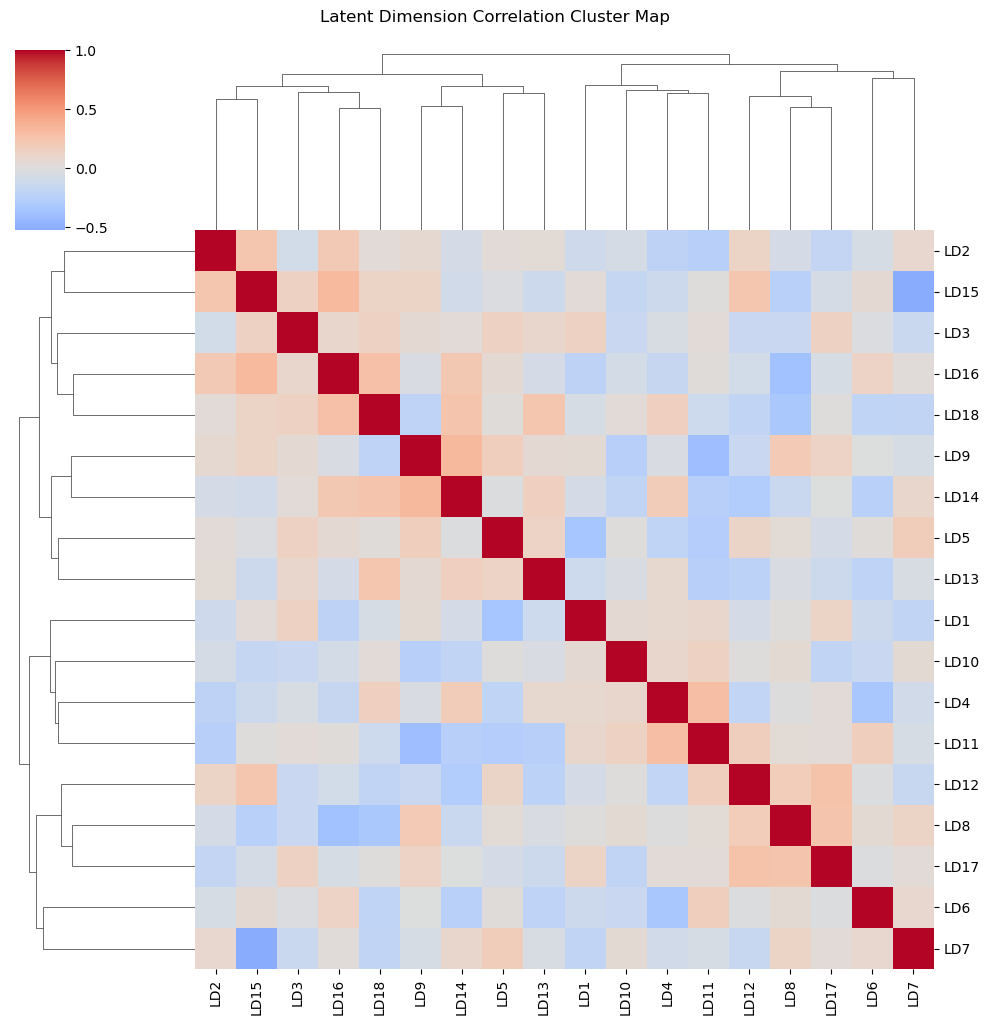

In [29]:
plt.figure(figsize=(12, 10))

cluster_fig = sns.clustermap(corr_matrix, cmap='coolwarm', center=0, figsize=(10, 10))
cluster_fig.fig.suptitle("Latent Dimension Correlation Cluster Map", y=1.02)
plt.show()

In [55]:
def disease_latent_correlation(disease_name):
    if disease_name == "Schizophrenia":
        is_disease = (result_test.values == 'Schizo').astype(int)
    elif disease_name == "AML":
        is_disease = (result_test.values == 'AML').astype(int)
    elif disease_name == "Diabetes":
        is_disease = (result_test.values == 'Diab').astype(int)
    else:
        raise ValueError("Invalid disease name.")

    # Extract the Latent Means for the test set
    # (Assuming latent_means was the output from your encoder)
    latent_cols = [f"LD{i+1}" for i in range(18)]
    df_latent_test = pd.DataFrame(latent_means, columns=latent_cols)

    correlations = {}
    for col in latent_cols:
        corr_r_val, corr_p_val = pearsonr(df_latent_test[col], is_disease)
        correlations[col] = corr_r_val, corr_p_val

    sorted_corrs = sorted(correlations.items(), key=lambda x: x[1][0], reverse=True)

    print(f"Top 5 Latent Dimensions Correlated with {disease_name}:")
    print(f"{'Dimension':<12} | {'Corr':<8} | {'P-Value':<10} | {'Significance'}")
    print("-" * 55)

    for ld, (corr, p_val) in sorted_corrs[:5]:
        # Determine significance stars
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        print(f"{ld:<12} | {corr:<8.4f} | {p_val:<10.2e} | {sig}")

In [59]:
disease_latent_correlation("Schizophrenia")
print()
disease_latent_correlation("AML")
print()
disease_latent_correlation("Diabetes")

Top 5 Latent Dimensions Correlated with Schizophrenia:
Dimension    | Corr     | P-Value    | Significance
-------------------------------------------------------
LD15         | 0.4313   | 3.36e-07   | ***
LD1          | 0.2594   | 2.99e-03   | **
LD11         | 0.2190   | 1.27e-02   | *
LD2          | 0.1664   | 5.94e-02   | ns
LD16         | 0.1390   | 1.16e-01   | ns

Top 5 Latent Dimensions Correlated with AML:
Dimension    | Corr     | P-Value    | Significance
-------------------------------------------------------
LD5          | 0.1648   | 6.20e-02   | ns
LD16         | 0.0934   | 2.92e-01   | ns
LD7          | 0.0876   | 3.24e-01   | ns
LD18         | 0.0773   | 3.84e-01   | ns
LD12         | 0.0724   | 4.15e-01   | ns

Top 5 Latent Dimensions Correlated with Diabetes:
Dimension    | Corr     | P-Value    | Significance
-------------------------------------------------------
LD9          | 0.3813   | 8.24e-06   | ***
LD8          | 0.3396   | 8.24e-05   | ***
LD7          | 0.2

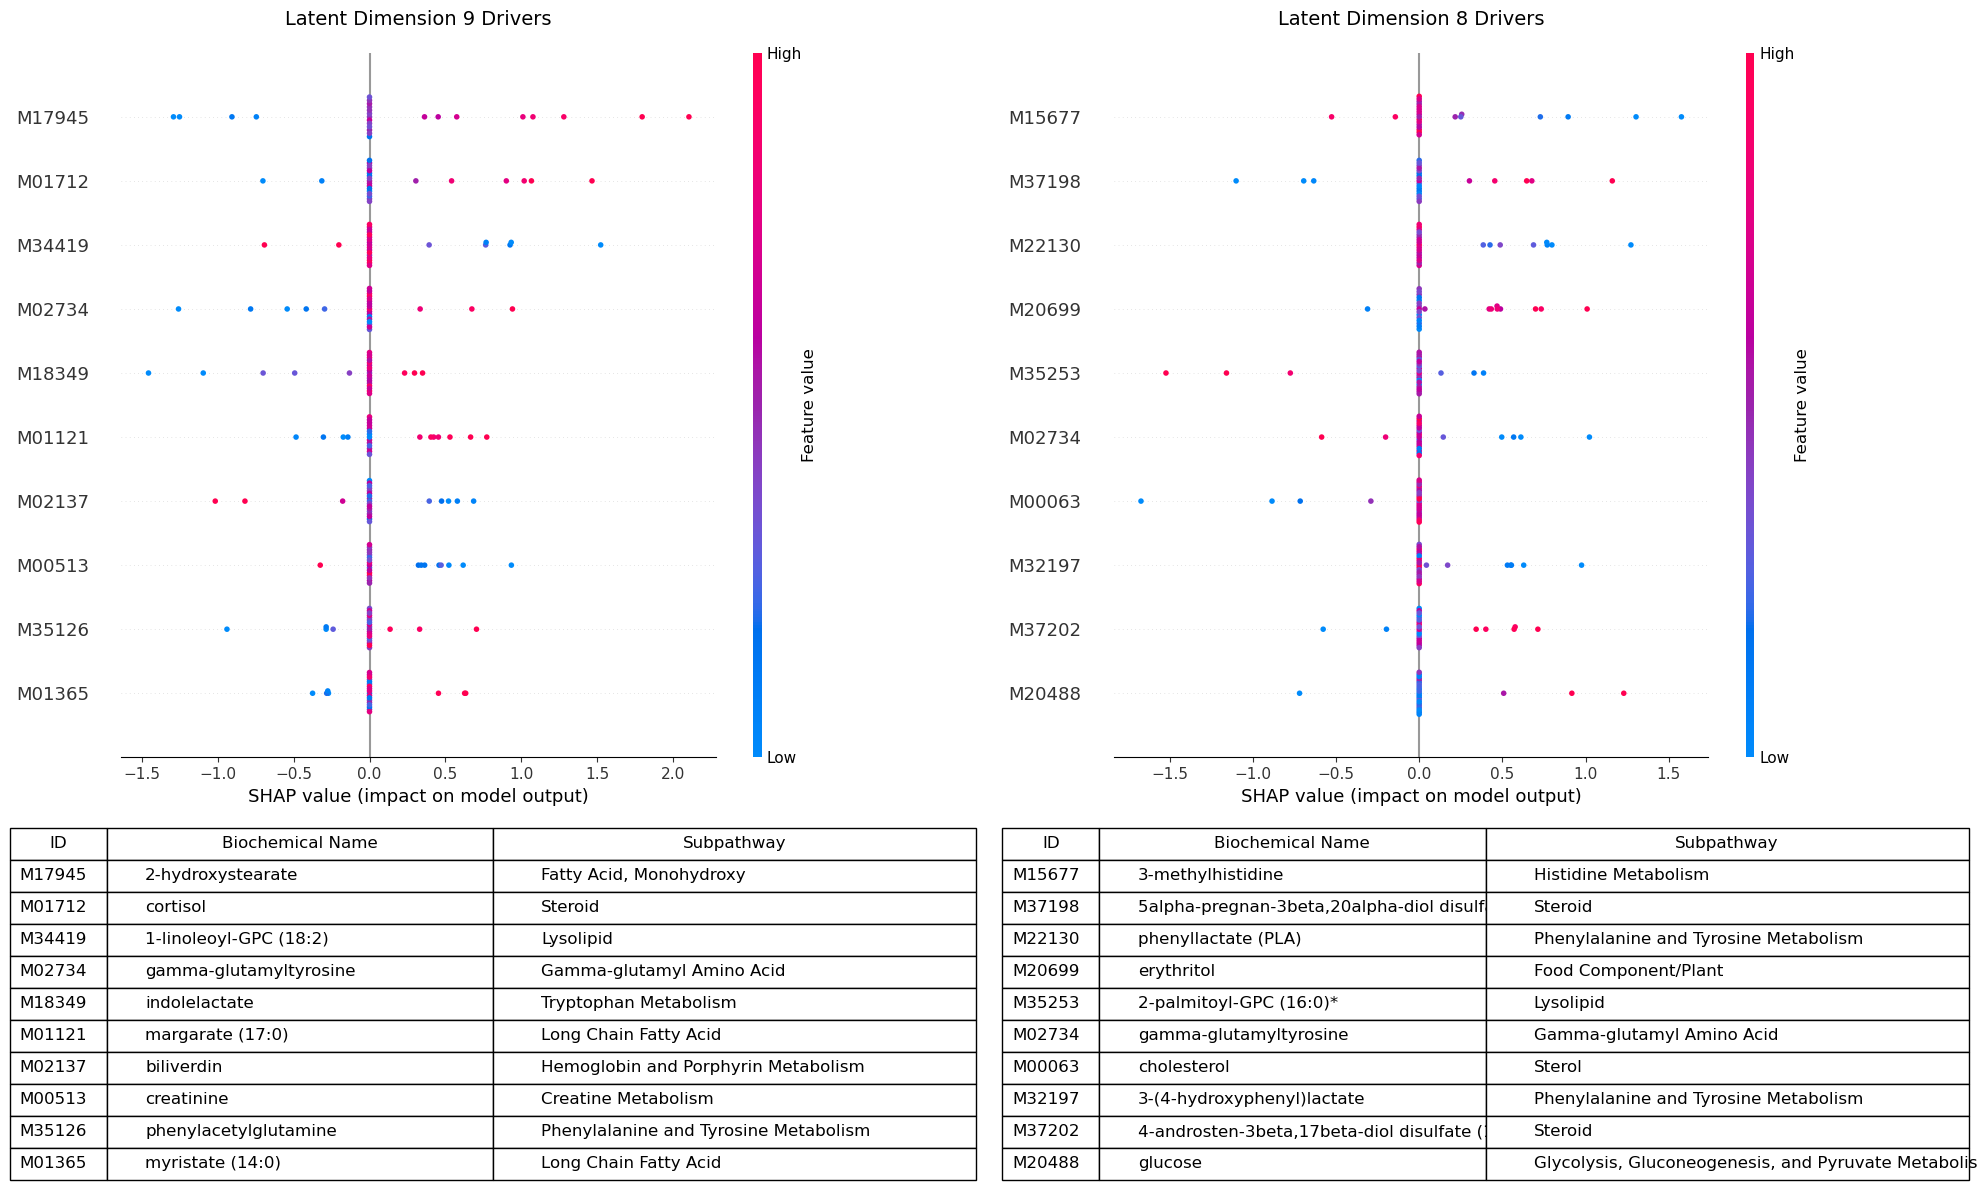

In [54]:
dim_1 = 9
dim_2 = 8

shap_values_T = np.transpose(shap_values, (2, 0, 1))

def shap_with_table(latent_dim, gs_slot):
    # 1. Create a nested grid: Top for SHAP, Bottom for Table
    inner_grid = gs_slot.subgridspec(2, 1, height_ratios=[3, 1], hspace=0.4)
    ax_shap = fig.add_subplot(inner_grid[0])
    ax_table = fig.add_subplot(inner_grid[1])

    # 2. Plot the SHAP plot on top
    plt.sca(ax_shap)
    shap.summary_plot(
        shap_values_T[latent_dim], 
        test_subset, 
        feature_names=metabolite_ids,
        max_display=10,
        show=False,
        plot_size=None
    )
    ax_shap.set_title(f"Latent Dimension {latent_dim} Drivers", fontsize=14, pad=20)

    # 3. Prepare the Metabolite Data for the table
    top_data = get_top_metabolites(shap_values_T[latent_dim], metabolite_ids)
    table_data = top_data[['BIOCHEMICAL', 'SUB_PATHWAY']].reset_index().values 

    # 4. Create the Table underneath
    ax_table.axis('off') # Hide the axes of the table slot
    tbl = ax_table.table(
        cellText=table_data,
        colLabels=['ID', 'Biochemical Name', 'Subpathway'],
        loc='center',
        cellLoc='left',
        bbox=[-0.15, 0, 1.3, 1.5] 
)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    
    col_widths = {0: 0.10, 1: 0.4, 2: 0.5}

    for (row, col), cell in tbl.get_celld().items():
        if col in col_widths:
            cell.set_width(col_widths[col])

# --- EXECUTION ---
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(1, 2) # 1 row, 2 columns of "slots"

shap_with_table(dim_1, gs[0])
shap_with_table(dim_2, gs[1])

plt.tight_layout()
plt.show()

In [48]:
is_diab = (result_test.values == 'AML').astype(int)

# Extract the Latent Means for the test set
# (Assuming latent_means was the output from your encoder)
latent_cols = [f"LD{i+1}" for i in range(18)]
df_latent_test = pd.DataFrame(latent_means, columns=latent_cols)

correlations = {}
for col in latent_cols:
    corr_r_val, corr_p_val = pearsonr(df_latent_test[col], is_schizo)
    correlations[col] = corr_r_val, corr_p_val

sorted_corrs = sorted(correlations.items(), key=lambda x: x[1][0], reverse=True)

print(f"{'Dimension':<12} | {'Corr':<8} | {'P-Value':<10} | {'Significance'}")
print("-" * 55)

for ld, (corr, p_val) in sorted_corrs[:5]:
    # Determine significance stars
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    
    print(f"{ld:<12} | {corr:<8.4f} | {p_val:<10.2e} | {sig}")

Dimension    | Corr     | P-Value    | Significance
-------------------------------------------------------
LD15         | 0.4313   | 3.36e-07   | ***
LD1          | 0.2594   | 2.99e-03   | **
LD11         | 0.2190   | 1.27e-02   | *
LD2          | 0.1664   | 5.94e-02   | ns
LD16         | 0.1390   | 1.16e-01   | ns
